# Дополнительное задание 4
# Выполнил: Ибраев Дамир Беркутбаевич
# Вариант 2.1

### Задание 1

1. Я импортировал данные наблюдений из CSV-файла. Затем я извлек значения признаков X и Y из таблицы. Поскольку в данных могли присутствовать пропущенные значения NaN, я удалил их из выборок, чтобы они не влияли на статистические расчеты. В результате я получил две очищенные выборки, которые используются в дальнейших вычислениях.

In [11]:
import pandas as pd
import numpy as np
from scipy import stats

df = pd.read_csv("Вариант 2_1.csv")

X = df["X"].dropna()
Y = df["Y"].dropna()

print("Размер X:", len(X))
print("Размер Y:", len(Y))

Размер X: 72
Размер Y: 92


2. Я вычислил объем выборки для каждого признака, а также выборочное среднее. Объем выборки показывает количество наблюдений, участвующих в анализе. Выборочное среднее является оценкой математического ожидания нормального распределения и показывает средний уровень значений признака.

In [12]:
n_X = len(X)
n_Y = len(Y)

mean_X = X.mean()
mean_Y = Y.mean()

print("n_X =", n_X)
print("mean_X =", mean_X)

print("n_Y =", n_Y)
print("mean_Y =", mean_Y)

n_X = 72
mean_X = 17.01361111111111
n_Y = 92
mean_Y = 21.601956521739133


3. Далее я построил доверительные интервалы для математического ожидания m нормального распределения при надежности 0.95. Для признака X по условию известно стандартное отклонение генеральной совокупности, поэтому я использовал нормальное распределение. Для признака Y стандартное отклонение неизвестно, поэтому я использовал распределение Стьюдента. Доверительные интервалы я получил двумя способами: с помощью функции interval и вручную через точность оценки.

In [13]:
gamma = 0.95
sigma_X = 7.5

ci_X_interval = stats.norm.interval(
    confidence=gamma,
    loc=mean_X,
    scale=sigma_X / np.sqrt(n_X)
)

z = stats.norm.ppf((1 + gamma) / 2)
delta_X = z * sigma_X / np.sqrt(n_X)
ci_X_manual = (mean_X - delta_X, mean_X + delta_X)

print(f"{ci_X_manual[0]:.6f} < m_X < {ci_X_manual[1]:.6f}")
print("Точность:", delta_X)

s_Y = Y.std(ddof=1)

ci_Y_interval = stats.t.interval(
    confidence=gamma,
    df=n_Y - 1,
    loc=mean_Y,
    scale=s_Y / np.sqrt(n_Y)
)

t = stats.t.ppf((1 + gamma) / 2, df=n_Y - 1)
delta_Y = t * s_Y / np.sqrt(n_Y)
ci_Y_manual = (mean_Y - delta_Y, mean_Y + delta_Y)

print(f"{ci_Y_manual[0]:.6f} < m_Y < {ci_Y_manual[1]:.6f}")
print("Точность:", delta_Y)

15.281231 < m_X < 18.745991
Точность: 1.7323797804370975
19.741805 < m_Y < 23.462108
Точность: 1.8601519653027647


4. На этом этапе я вычислил исправленное выборочное среднее квадратическое отклонение для признака Y. Исправленное отклонение используется как оценка стандартного отклонения генеральной совокупности и рассчитывается с учетом числа степеней свободы.

In [14]:
s_Y = Y.std(ddof=1)
print("s_Y =", s_Y)

s_Y = 8.982156700208467


5. Далее я построил доверительный интервал для стандартного отклонения σ нормального распределения признака Y. Для построения интервала я использовал распределение хи-квадрат, так как интервал строится для дисперсии и стандартного отклонения генеральной совокупности.

In [15]:
chi2_left = stats.chi2.ppf((1 + gamma) / 2, df=n_Y - 1)
chi2_right = stats.chi2.ppf((1 - gamma) / 2, df=n_Y - 1)

sigma_low = np.sqrt((n_Y - 1) * s_Y**2 / chi2_left)
sigma_high = np.sqrt((n_Y - 1) * s_Y**2 / chi2_right)

print(f"{sigma_low:.6f} < sigma_Y < {sigma_high:.6f}")

7.845382 < sigma_Y < 10.507230


Интервалы в виде двойных неравенств: 

15.281231<𝑚x​<18.745991

19.741805<𝑚y<23.462108

7.845382<σy​<10.507230

6. На этом этапе я построил доверительные интервалы для математического ожидания признака X для нескольких других значений надежности. Это позволило мне сравнить ширину интервалов и точность оценки при разных значениях надежности.

In [16]:
gammas = [0.80, 0.90, 0.99]

for g in gammas:
    z = stats.norm.ppf((1 + g) / 2)
    delta = z * sigma_X / np.sqrt(n_X)
    left = mean_X - delta
    right = mean_X + delta
    
    print("\nНадежность:", g)
    print(f"{left:.6f} < m_X < {right:.6f}")
    print("Точность:", delta)


Надежность: 0.8
15.880869 < m_X < 18.146353
Точность: 1.1327422530460292

Надежность: 0.9
15.559752 < m_X < 18.467470
Точность: 1.453858942095842

Надежность: 0.99
14.736878 < m_X < 19.290344
Точность: 2.276732959648062


7. Проанализировав полученные доверительные интервалы для различных значений надежности, я сделал вывод, что при увеличении надежности доверительного интервала его ширина увеличивается, а точность оценки уменьшается. При уменьшении надежности интервал сужается, и точность оценки увеличивается. Следовательно, между надежностью и точностью доверительного интервала существует обратная зависимость: чем выше надежность, тем меньше точность, и наоборот.

8. Проанализировав полученные доверительные интервалы для различных значений надежности, я сделал вывод, что при увеличении надежности доверительного интервала его ширина увеличивается, а точность оценки уменьшается. При уменьшении надежности интервал сужается, и точность оценки увеличивается. Следовательно, между надежностью и точностью доверительного интервала существует обратная зависимость: чем выше надежность, тем меньше точность, и наоборот.

### Задание 2

1. На этом этапе я загрузил файл с данными клиентов банка и выделил два признака, которые нужны для анализа: возраст клиента и продолжительность разговора с сотрудником банка. Затем я удалил возможные пропуски, чтобы расчеты выполнялись только по корректным наблюдениям. Также подключил библиотеку matplotlib

In [19]:
import matplotlib.pyplot as plt

df_bank = pd.read_csv("Данные_клиентов.txt", sep="\t")

data_corr = df_bank[["Возраст", "Продолжительность разговора, сек."]].dropna()

print("Размер выборки:", len(data_corr))
print(data_corr.head())

Размер выборки: 41188
   Возраст  Продолжительность разговора, сек.
0       56                                261
1       57                                149
2       37                                226
3       40                                151
4       56                                307


2. Далее я вычислил основные описательные характеристики для возраста и продолжительности разговора. Это позволяет понять общий масштаб данных, средние значения, разброс и возможное наличие выбросов.

In [20]:
print(data_corr.describe())

           Возраст  Продолжительность разговора, сек.
count  41188.00000                       41188.000000
mean      40.02406                         258.285010
std       10.42125                         259.279249
min       17.00000                           0.000000
25%       32.00000                         102.000000
50%       38.00000                         180.000000
75%       47.00000                         319.000000
max       98.00000                        4918.000000


Я вижу, что продолжительность разговора имеет очень большой разброс. Это уже на предварительном этапе позволяет предположить, что связь, если и есть, может быть слабой и визуально размытой из-за выбросов и высокой вариативности.

3. Чтобы визуально оценить взаимосвязь между возрастом клиента и продолжительностью разговора, я построил диаграмму рассеяния. Если бы между признаками существовала выраженная линейная зависимость, точки на графике располагались бы вдоль возрастающей или убывающей полосы. Если точки распределены хаотично, это говорит об отсутствии заметной связи.

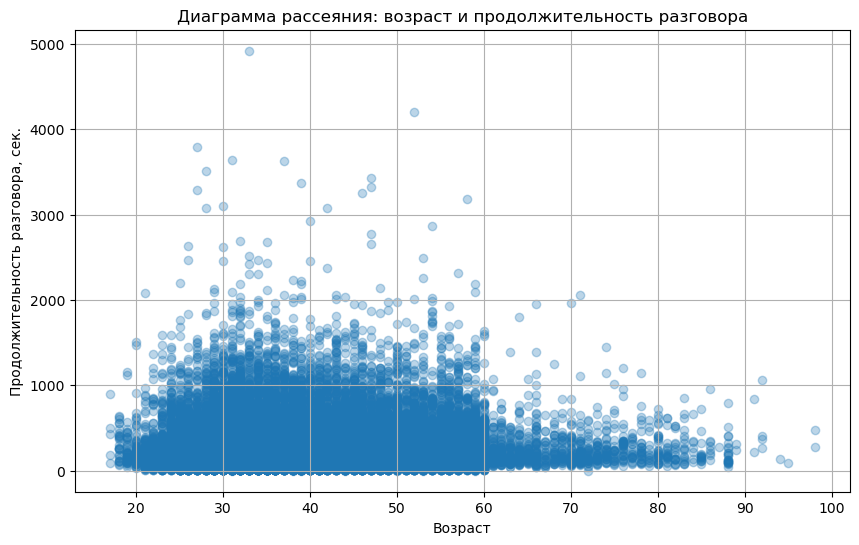

In [22]:
plt.figure(figsize=(10, 6))
plt.scatter(
    data_corr["Возраст"],
    data_corr["Продолжительность разговора, сек."],
    alpha=0.3
)
plt.xlabel("Возраст")
plt.ylabel("Продолжительность разговора, сек.")
plt.title("Диаграмма рассеяния: возраст и продолжительность разговора")
plt.grid(True)
plt.show()

По диаграмме рассеяния я не наблюдаю выраженного возрастающего или убывающего тренда. Точки распределены достаточно хаотично, поэтому визуально сильной зависимости между возрастом клиента и продолжительностью разговора не видно.

4. Далее я вычислил коэффициент корреляции Пирсона, чтобы количественно оценить линейную связь между возрастом и продолжительностью разговора. Также я посмотрел p-value, чтобы проверить статистическую значимость этой связи.

In [23]:
pearson_r, pearson_p = stats.pearsonr(
    data_corr["Возраст"],
    data_corr["Продолжительность разговора, сек."]
)

print("Коэффициент корреляции Пирсона:", pearson_r)
print("p-value:", pearson_p)

Коэффициент корреляции Пирсона: -0.0008657050101409441
p-value: 0.8605390363326673


Полученный коэффициент корреляции Пирсона практически равен нулю. Это означает, что линейная связь между возрастом клиента и продолжительностью разговора фактически отсутствует. Кроме того, p-value значительно больше 0.05, следовательно, статистически значимой линейной зависимости я не обнаружил.

5. Поскольку продолжительность разговора имеет заметный разброс и возможные выбросы, дополнительно я вычислил коэффициент корреляции Спирмена. Этот показатель позволяет проверить наличие монотонной связи, которая может быть не обязательно линейной.

In [24]:
spearman_rho, spearman_p = stats.spearmanr(
    data_corr["Возраст"],
    data_corr["Продолжительность разговора, сек."]
)

print("Коэффициент корреляции Спирмена:", spearman_rho)
print("p-value:", spearman_p)

Коэффициент корреляции Спирмена: -0.0021225520320207027
p-value: 0.6666460333859638


Коэффициент Спирмена также очень близок к нулю, а p-value снова больше 0.05. Это подтверждает, что заметной монотонной связи между возрастом клиента и продолжительностью разговора также нет.

6. Проанализировав взаимосвязь между возрастом клиента и продолжительностью разговора, я пришел к выводу, что выраженной зависимости между этими признаками нет. Диаграмма рассеяния не показывает заметного тренда, а коэффициенты корреляции Пирсона и Спирмена оказались близки к нулю. Кроме того, соответствующие p-value значительно превышают уровень значимости 0.05. Следовательно, на основании проведенного анализа я делаю вывод, что возраст клиента практически не связан с продолжительностью его разговора с сотрудником банка.

### Задание 3

1. На этом этапе я выделил категориальные признаки, которые потенциально могут влиять на целевой признак «Отклик». Далее я рассматриваю отклик как категориальную переменную с двумя значениями: Да и Нет. Для корректного анализа я также заменяю пропуски в категориальных признаках отдельной категорией, чтобы не терять наблюдения.

In [25]:
cat_cols = [
    "Направление деятельности",
    "Семейное положение",
    "Образование",
    "Дефолты",
    "Ипотека",
    "Потребительский кредит",
    "Тип звонка",
    "Месяц последнего контакта",
    "День недели последнего контакта",
    "Результат предыдущей кампании"
]

df_cat = df_bank.copy()

for col in cat_cols:
    df_cat[col] = df_cat[col].fillna("Пропуск")

df_cat["Отклик"] = df_cat["Отклик"].fillna("Пропуск")

2. Далее я решил оценить силу связи каждого категориального признака с откликом. Для этого я использовал критерий хи-квадрат Пирсона и коэффициент Крамера V. Критерий хи-квадрат позволяет проверить наличие статистически значимой зависимости, а коэффициент Крамера показывает силу этой зависимости. Чем больше значение V, тем сильнее связь признака с откликом.

In [27]:
from scipy.stats import chi2_contingency
import math

def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.to_numpy().sum()
    r, k = table.shape
    return math.sqrt((chi2 / n) / min(r - 1, k - 1))

results = []

for col in cat_cols:
    table = pd.crosstab(df_cat[col], df_cat["Отклик"])
    chi2, p, dof, expected = chi2_contingency(table)
    v = cramers_v(df_cat[col], df_cat["Отклик"])
    
    results.append({
        "Признак": col,
        "chi2": chi2,
        "p-value": p,
        "Cramers_V": v
    })

results_df = pd.DataFrame(results).sort_values(by="Cramers_V", ascending=False)
print(results_df)

                           Признак         chi2        p-value  Cramers_V
9    Результат предыдущей кампании  4230.523798   0.000000e+00   0.320488
7        Месяц последнего контакта  3101.149351   0.000000e+00   0.274395
0         Направление деятельности   961.242440  4.189763e-199   0.152768
6                       Тип звонка   862.318364  1.525986e-189   0.144693
3                          Дефолты   406.577515   5.161958e-89   0.099354
2                      Образование   193.105905   3.305189e-38   0.068472
1               Семейное положение   122.655152   2.068015e-26   0.054570
8  День недели последнего контакта    26.144939   2.958482e-05   0.025195
4                          Ипотека     5.684496   5.829448e-02   0.011748
5           Потребительский кредит     1.094028   5.786753e-01   0.005154


Я вижу, что наиболее сильную связь с откликом показывают признаки результат предыдущей кампании, месяц последнего контакта и направление деятельности. Признаки ипотека и потребительский кредит практически не связаны с откликом.

3. После ранжирования признаков я дополнительно посмотрел, как именно меняется доля положительного отклика в разных категориях. Это позволяет не просто установить наличие связи, а понять ее содержательно.

In [28]:
top_features = [
    "Результат предыдущей кампании",
    "Месяц последнего контакта",
    "Направление деятельности"
]

for col in top_features:
    print("\n", col)
    response_rate = pd.crosstab(
        df_cat[col],
        df_cat["Отклик"],
        normalize="index"
    ) * 100
    
    print(response_rate.round(2))


 Результат предыдущей кампании
Отклик                            Да    Нет
Результат предыдущей кампании              
Не применимо                    8.83  91.17
Неуспех                        14.23  85.77
Успех                          65.11  34.89

 Месяц последнего контакта
Отклик                        Да    Нет
Месяц последнего контакта              
август                     10.60  89.40
апрель                     20.48  79.52
декабрь                    48.90  51.10
июль                        9.05  90.95
июнь                       10.51  89.49
май                         6.43  93.57
март                       50.55  49.45
ноябрь                     10.14  89.86
октябрь                    43.87  56.13
сентябрь                   44.91  55.09

 Направление деятельности
Отклик                            Да    Нет
Направление деятельности                   
Безработный                    14.20  85.80
Домработница                   10.00  90.00
Пенсионер                      25.23 

4. Сначала я рассмотрел признак «Результат предыдущей кампании», поскольку он показал наибольшую силу связи с откликом.

Доля положительного отклика по этому признаку примерно такая:

Успех - 65.11%

Неуспех - 14.23%

Не применимо - 8.83%

Результат предыдущей кампании является самым сильным категориальным фактором. Если предыдущий контакт с клиентом был успешным, вероятность положительного отклика в текущей кампании существенно выше.

5. Затем я рассмотрел признак «Месяц последнего контакта», который также показал высокую силу связи с откликом.

Наиболее высокие доли положительного отклика наблюдаются, например, в следующих месяцах:

март - 50.55%

декабрь - 48.90%

сентябрь - 44.91%

октябрь - 43.87%

Наиболее низкие доли отклика:

май - 6.43%

июль - 9.05%

ноябрь - 10.14%

июнь - 10.51%

Я вижу, что месяц контакта заметно влияет на вероятность отклика. Это означает, что временной фактор и сезонность маркетинговой кампании действительно важны для результата.

6. Далее я проанализировал признак «Направление деятельности», который также вошел в число наиболее значимых.

Наибольшая доля положительного отклика наблюдается у следующих категорий:

Студент → 31.43%

Пенсионер → 25.23%

Безработный → 14.20%

Наименьшая доля положительного отклика наблюдается, например, у:

Синий воротничок → 6.89%

Сфера услуг → 8.14%

Предприниматель → 8.52%

Профессиональная группа клиента действительно влияет на отклик. Вероятность положительной реакции на предложение банка различается между категориями занятости, поэтому данный признак можно считать значимым для построения модели.

7. Я включил три наиболее сильных признака, отдельно отмечаю, что признак «Тип звонка» тоже показывает заметную связь с откликом.

Доли положительного отклика:

Мобильный - 14.74%

Стационарный - 5.23%

Этот признак тоже можно считать полезным для модели, хотя по силе связи он немного уступает признаку «Направление деятельности».

8. Проанализировав влияние категориальных признаков на целевой признак «Отклик», я пришел к выводу, что наиболее значимыми являются: результат предыдущей кампании, месяц последнего контакта, направление деятельности

Именно эти признаки показали наибольшую силу связи с откликом по коэффициенту Крамера. Кроме того, содержательный анализ долей положительного отклика по категориям подтвердил, что различия между группами действительно существенны. Также я отметил, что признак «Тип звонка» тоже может быть полезен для модели, хотя его влияние немного слабее. В то же время признаки «Ипотека» и «Потребительский кредит» показали очень слабую связь с откликом и, вероятно, не являются приоритетными для включения в предсказательную модель.